# SMS Spam Detection

## Importing necessary libraries

In [1]:
!pip install optuna -q
!pip install imbalanced-learn -q
!pip install catboost -q
!pip install nltk -q

In [2]:
import re
import nltk
import pickle
import joblib
import optuna
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from optuna.storages import RDBStorage
from optuna.samplers import TPESampler
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, \
 f1_score, confusion_matrix, classification_report, matthews_corrcoef, \
 roc_auc_score, roc_curve, ConfusionMatrixDisplay, fbeta_score, precision_recall_curve, \
 make_scorer

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("All libraries has been imported!")

All libraries has been imported!


## Loading the dataset

In [3]:
# Set the path to the file you'd like to load
file_path = "spam.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/sms-spam-collection-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
  pandas_kwargs={'encoding': 'latin-1'}
)

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## EDA

In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5572
Number of columns: 5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [8]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [9]:
round(df.isnull().sum() / df.shape[0] * 100, 2)

,0
v1,0.000
v2,0.000
Unnamed: 2,99.100
Unnamed: 3,99.780
Unnamed: 4,99.890


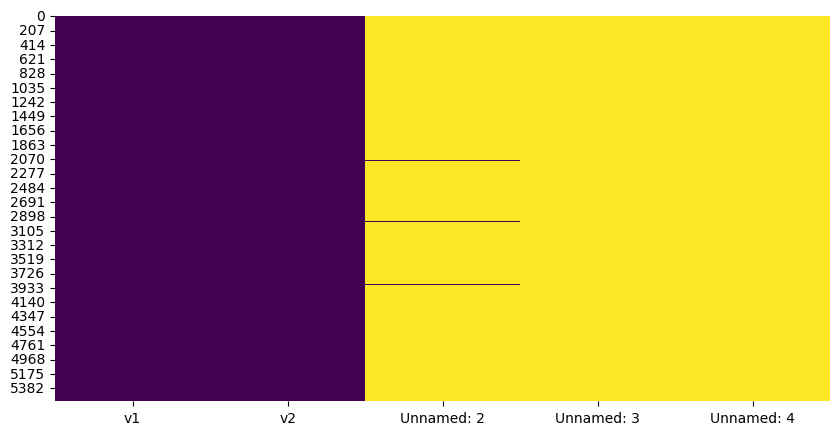

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [11]:
print(f"Number of unique values in 'v1' column: {df['v1'].nunique()}")
print(f"Number of unique values in 'v2' column: {df['v2'].nunique()}")

Number of unique values in 'v1' column: 2
Number of unique values in 'v2' column: 5169


In [12]:
print(f"Number of duplicated values is {df.duplicated().sum()}")

Number of duplicated values is 403


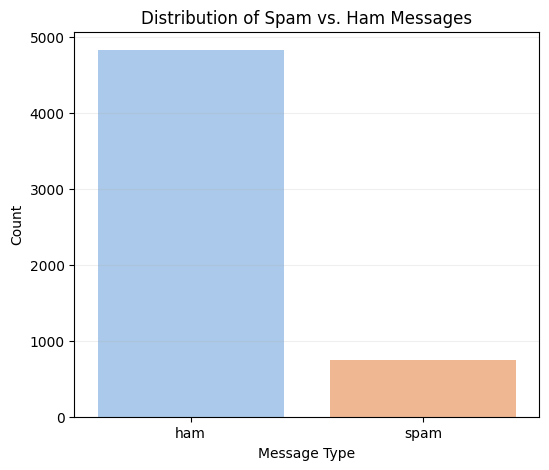

In [13]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='v1', hue='v1', palette='pastel')
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.2)
plt.show()

In [14]:
fig = go.Figure(data=[
    go.Pie(
        labels=df['v1'].value_counts().index,
        values=df['v1'].value_counts().values,
        hole=0.4,
        textinfo='label+percent',
        marker=dict(colors=['#00BFA6', '#6A5ACD'])
    )
])
fig.update_layout(title_text='Distribution of Spam vs. Ham Messages')
fig.show()

## Data Preprocessing

In [15]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
encoder = LabelEncoder()
df['v1'] = encoder.fit_transform(df['v1'])

In [18]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
X = df.drop('v1', axis=1)
y = df['v1']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
X_train = X_train.squeeze()
X_test = X_test.squeeze()

In [22]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (4135,)
X_test shape: (1034,)
y_train shape: (4135,)
y_test shape: (1034,)


In [23]:
class TextCleaner(BaseEstimator, TransformerMixin):
    """
    A custom transformer for basic text cleaning:
    - Lowercasing
    - Removing punctuation
    - Removing numbers
    - Removing extra whitespaces
    - Removing URLs and emails
    - Removing special characters (e.g., @, #)
    """

    def __init__(self, remove_numbers=True, remove_urls=True):
        self.remove_numbers = remove_numbers
        self.remove_urls = remove_urls

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.apply(self._clean_text)

    def _clean_text(self, text):
        # Ensure the input is treated as a string
        text = str(text)

        # 1. Lowercase
        text = text.lower()

        # 2. Remove URLs and emails
        if self.remove_urls:
            text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
            text = re.sub(r'\S+@\S+', '', text)

        # 3. Remove punctuation and special characters
        text = re.sub(r"[^\w\s]", " ", text)

        # 4. Remove numbers
        if self.remove_numbers:
            text = re.sub(r'\d+', '', text)

        # 5. Remove multiple whitespaces
        text = re.sub(r'\s+', ' ', text).strip()

        return text

In [24]:
input_text = "FREE!!! Get your prize now 😎. Visit: https://free-prize.com #Winner123"

output_text = TextCleaner()._clean_text(input_text)

print(output_text)

free get your prize now visit winner


In [25]:
nltk.download('stopwords', quiet=True)

class StopwordsRemover(BaseEstimator, TransformerMixin):
    """
    Custom transformer to remove stopwords from text.
    Input: Series of strings
    Output: Series of strings with stopwords removed
    """

    def __init__(self, lang='english'):
      self.lang = lang
      self.stopwords = set(stopwords.words(lang))

    def fit(self, X, y=None):
      return self

    def transform(self, X):
      return X.apply(self._remove_stopwords)

    def _remove_stopwords(self, text):
      words = text.split()
      filtered = [word for word in words if word not in self.stopwords]
      return ' '.join(filtered)

In [26]:
text = "This is an example of how we remove the most common words from a sentence"
StopwordsRemover()._remove_stopwords(text)

'This example remove common words sentence'

In [27]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

class Stemmer(BaseEstimator, TransformerMixin):
  """
  Custom transformer to perform stemming on text.
  Input: Series of strings
  Output: Series of strings with stemmed words
  """
  def __init__(self):
    self.stemmer = PorterStemmer()

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X.apply(self._stem_text)

  def _stem_text(self, text):
    words = word_tokenize(text)
    stemmed = [self.stemmer.stem(word) for word in words]
    return ' '.join(stemmed)

In [28]:
text = "running runners easily played better"
print(Stemmer()._stem_text(text))

run runner easili play better


In [29]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cleaner = TextCleaner()
        self.stop = StopwordsRemover()
        self.stem = Stemmer()
        self.vectorizer = TfidfVectorizer(
            max_features=3000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            norm='l2'
        )

    def fit(self, X, y=None):
        # Fit each component individually
        X_cleaned = self.cleaner.fit_transform(X)
        X_stopwords_removed = self.stop.fit_transform(X_cleaned)
        X_stemmed = self.stem.fit_transform(X_stopwords_removed)
        self.vectorizer.fit(X_stemmed)
        return self

    def transform(self, X):
        # Transform each component individually
        X_cleaned = self.cleaner.transform(X)
        X_stopwords_removed = self.stop.transform(X_cleaned)
        X_stemmed = self.stem.transform(X_stopwords_removed)
        return self.vectorizer.transform(X_stemmed)

In [30]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', TextPreprocessor()),
    ('adasyn', ADASYN(random_state=42)),
    ('model', XGBClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('adasyn', ADASYN(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [31]:
# Get the fitted preprocessor from the pipeline
fitted_preprocessor = pipeline.named_steps['preprocessor']

# Transform the training and testing data
X_train_preprocessed = fitted_preprocessor.transform(X_train)
X_test_preprocessed = fitted_preprocessor.transform(X_test)

# Get feature names
feature_names = fitted_preprocessor.vectorizer.get_feature_names_out()

# Convert sparse matrices to dense arrays if needed for further processing or visualization
# Note: For many models, keeping the data in sparse format is more efficient
X_train_dense = X_train_preprocessed.toarray()
X_test_dense = X_test_preprocessed.toarray()

# Create DataFrames (optional, can work with sparse matrices directly with many models)
X_train_preprocessed_df = pd.DataFrame(X_train_dense, columns=feature_names)
X_test_preprocessed_df = pd.DataFrame(X_test_dense, columns=feature_names)

# Display the shapes of the preprocessed data
print("Shape of X_train_preprocessed:", X_train_preprocessed.shape)
print("Shape of X_test_preprocessed:", X_test_preprocessed.shape)

# Display the shapes of the dense arrays (if created)
print("Shape of X_train_dense:", X_train_dense.shape)
print("Shape of X_test_dense:", X_test_dense.shape)

Shape of X_train_preprocessed: (4135, 3000)
Shape of X_test_preprocessed: (1034, 3000)
Shape of X_train_dense: (4135, 3000)
Shape of X_test_dense: (1034, 3000)


In [32]:
X_train_preprocessed_df.head()

aah  aathi   abi  abil  abiola   abl  abl come  abl get   abt    ac   acc  \
0 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
1 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
2 0.000  0.000 0.000 0.000   0.000 0.310     0.000    0.000 0.000 0.000 0.000   
3 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
4 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   

   accept  access  accid  accident  account  account detail  \
0   0.000   0.000  0.000     0.000    0.000           0.000   
1   0.000   0.000  0.000     0.000    0.000           0.000   
2   0.000   0.000  0.000     0.000    0.000           0.000   
3   0.000   0.000  0.000     0.000    0.000           0.000   
4   0.000   0.000  0.000     0.000    0.000           0.000   

   account statement   ach  across  across sea  action  activ  actual    ad  \
0              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
1              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
2              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
3              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
4              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   

    add  addi  address  admir  admir look  ador  adult  advanc  advic  advis  \
0 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
1 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
2 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
3 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
4 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   

   affair  afraid   aft  aft ur  afternoon  afternoon love   age  \
0   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
1   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
2   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
3   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
4   0.000   0.000 0.000   0.000      0.000           0.000 0.000   

   age perwksub   ago    ah   aha  ahead  ahmad  aight  aint   air  aiya  \
0         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
1         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
2         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
3         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
4         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   

   aiyah  aiyar  aiyo    al  album  alcohol  alert  alex  aliv  allah  allow  \
0  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
1  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
2  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
3  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
4  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   

   almost  alon  alreadi  alreadi got  alright  alrit  also  alway  amaz  \
0   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
1   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
2   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
3   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
4   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   

    ami  among  amount   amp    an  angri  announc  anoth  anoth friend  \
0 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
1 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
2 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
3 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
4 0

In [33]:
X_test_preprocessed_df.head()

aah  aathi   abi  abil  abiola   abl  abl come  abl get   abt    ac   acc  \
0 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
1 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
2 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
3 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   
4 0.000  0.000 0.000 0.000   0.000 0.000     0.000    0.000 0.000 0.000 0.000   

   accept  access  accid  accident  account  account detail  \
0   0.000   0.000  0.000     0.000    0.000           0.000   
1   0.000   0.000  0.000     0.000    0.000           0.000   
2   0.000   0.000  0.000     0.000    0.000           0.000   
3   0.000   0.000  0.000     0.000    0.000           0.000   
4   0.000   0.000  0.000     0.000    0.000           0.000   

   account statement   ach  across  across sea  action  activ  actual    ad  \
0              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
1              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
2              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
3              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   
4              0.000 0.000   0.000       0.000   0.000  0.000   0.000 0.000   

    add  addi  address  admir  admir look  ador  adult  advanc  advic  advis  \
0 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
1 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
2 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
3 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   
4 0.000 0.000    0.000  0.000       0.000 0.000  0.000   0.000  0.000  0.000   

   affair  afraid   aft  aft ur  afternoon  afternoon love   age  \
0   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
1   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
2   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
3   0.000   0.000 0.000   0.000      0.000           0.000 0.000   
4   0.000   0.000 0.000   0.000      0.000           0.000 0.000   

   age perwksub   ago    ah   aha  ahead  ahmad  aight  aint   air  aiya  \
0         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
1         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
2         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
3         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.000   
4         0.000 0.000 0.000 0.000  0.000  0.000  0.000 0.000 0.000 0.465   

   aiyah  aiyar  aiyo    al  album  alcohol  alert  alex  aliv  allah  allow  \
0  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
1  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
2  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
3  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   
4  0.000  0.000 0.000 0.000  0.000    0.000  0.000 0.000 0.000  0.000  0.000   

   almost  alon  alreadi  alreadi got  alright  alrit  also  alway  amaz  \
0   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
1   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
2   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
3   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   
4   0.000 0.000    0.000        0.000    0.000  0.000 0.000  0.000 0.000   

    ami  among  amount   amp    an  angri  announc  anoth  anoth friend  \
0 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
1 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
2 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
3 0.000  0.000   0.000 0.000 0.000  0.000    0.000  0.000         0.000   
4 0

## Modeling and Evaluating

In [34]:
def evaluate_model_full(model, X_train, y_train, X_test, y_test, model_name, result_df, beta=2, k=5):
    # Convert y_train and y_test to NumPy arrays for consistent indexing
    y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train
    y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

    # ---------- Cross-Validation ----------
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    metrics_cv = {k: [] for k in ['acc', 'prec', 'rec', 'f1', 'fbeta', 'mcc', 'roc_auc']}
    all_y_true_cv = []
    all_y_probs_cv = []

    # Convert to DataFrame for cross-validation
    if hasattr(X_train, 'iloc'):
        X_train_df = X_train
    else:
        X_train_df = pd.DataFrame(X_train)

    for train_idx, val_idx in skf.split(X_train_df, y_train_np): # Use y_train_np here
        X_tr, X_val = X_train_df.iloc[train_idx], X_train_df.iloc[val_idx]
        y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx] # Use y_train_np here

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        try:
            y_prob_val = model.predict_proba(X_val)[:, 1]
        except:
            y_prob_val = model.decision_function(X_val)
            y_prob_val = (y_prob_val - y_prob_val.min()) / (y_prob_val.max() - y_prob_val.min())


        metrics_cv['acc'].append(balanced_accuracy_score(y_val, y_pred_val))
        metrics_cv['prec'].append(precision_score(y_val, y_pred_val))
        metrics_cv['rec'].append(recall_score(y_val, y_pred_val))
        metrics_cv['f1'].append(f1_score(y_val, y_pred_val))
        metrics_cv['fbeta'].append(fbeta_score(y_val, y_pred_val, beta=beta))
        metrics_cv['mcc'].append(matthews_corrcoef(y_val, y_pred_val))
        metrics_cv['roc_auc'].append(roc_auc_score(y_val, y_prob_val))

        all_y_true_cv.extend(y_val)
        all_y_probs_cv.extend(y_prob_val)

    # ---------- Evaluation on Test Set ----------
    # Use DataFrame for testing
    model.fit(X_train, y_train_np) # Fit on the full training DataFrame, use y_train_np
    y_pred_test = model.predict(X_test)
    try:
        y_prob_test = model.predict_proba(X_test)[:, 1]
    except:
        y_prob_test = model.decision_function(X_test)
        y_prob_test = (y_prob_test - y_prob_test.min()) / (y_prob_test.max() - y_prob_test.min())


    acc_test = balanced_accuracy_score(y_test_np, y_pred_test) # Use y_test_np here
    prec_test = precision_score(y_test_np, y_pred_test) # Use y_test_np here
    rec_test = recall_score(y_test_np, y_pred_test) # Use y_test_np here
    f1_test = f1_score(y_test_np, y_pred_test) # Use y_test_np here
    fbeta_test = fbeta_score(y_test_np, y_pred_test, beta=beta) # Use y_test_np here
    mcc_test = matthews_corrcoef(y_test_np, y_pred_test) # Use y_test_np here
    roc_auc_test = roc_auc_score(y_test_np, y_prob_test) # Use y_test_np here

    # ---------- Plot ROC & PR on Test Set ----------
    fpr, tpr, _ = roc_curve(y_test_np, y_prob_test) # Use y_test_np here
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_np, y_prob_test) # Use y_test_np here

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_test:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recall_curve, precision_curve)
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.tight_layout()
    plt.show()

    # ---------- Add to Results ----------
    new_row = pd.DataFrame([{
        'Model': model_name,
        # Train (CV)
        'Train Accuracy': np.mean(metrics_cv['acc']),
        'Train Precision': np.mean(metrics_cv['prec']),
        'Train Recall': np.mean(metrics_cv['rec']),
        'Train F1': np.mean(metrics_cv['f1']),
        'Train Fβ': np.mean(metrics_cv['fbeta']),
        'Train MCC': np.mean(metrics_cv['mcc']),
        'Train ROC AUC': np.mean(metrics_cv['roc_auc']),
        # Test
        'Test Accuracy': acc_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F1': f1_test,
        'Test Fβ': fbeta_test,
        'Test MCC': mcc_test,
        'Test ROC AUC': roc_auc_test,
    }])

    result_df = pd.concat([result_df, new_row], ignore_index=True)
    return result_df

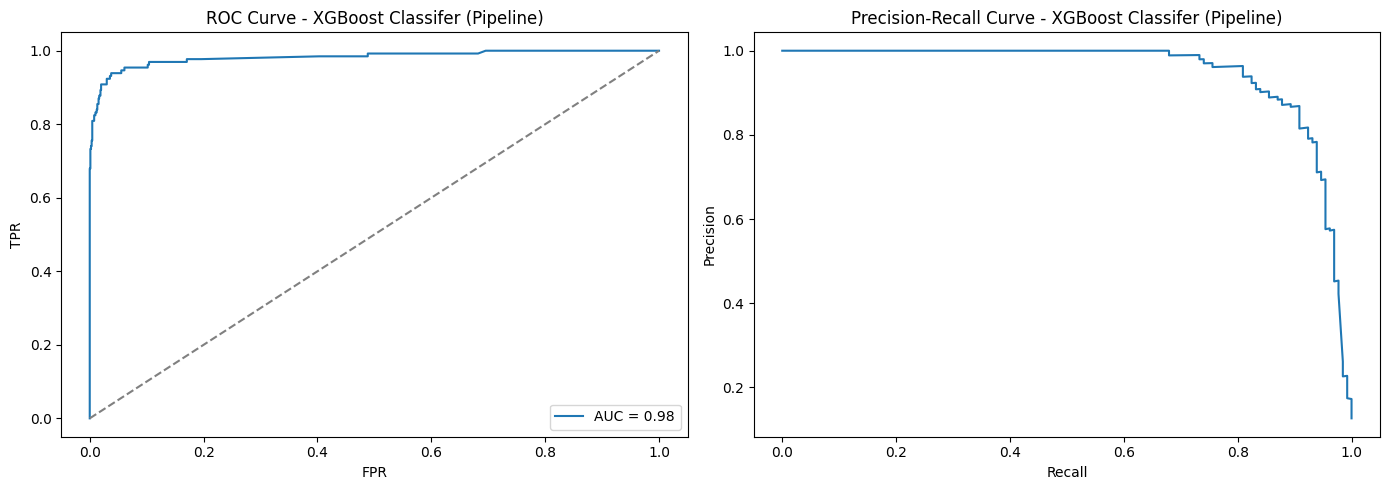

In [35]:
pipeline_result = pd.DataFrame()

pipeline_result = evaluate_model_full(
    pipeline,
    X_train, y_train,
    X_test, y_test,
    "XGBoost Classifer (Pipeline)",
    pipeline_result
)

In [36]:
pipeline_result

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Train Fβ,Train MCC,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test Fβ,Test MCC,Test ROC AUC
0,XGBoost Classifer (Pipeline),0.904,0.903,0.820,0.859,0.835,0.842,0.967,0.927,0.884,0.870,0.877,0.873,0.859,0.982


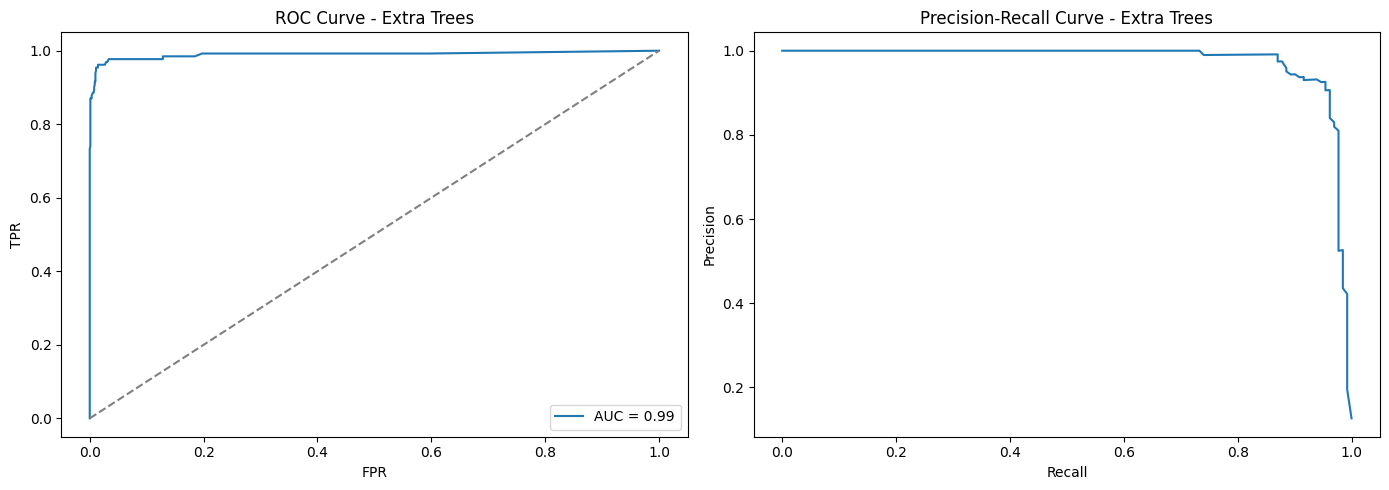

In [37]:
classifiers = {
    # 'Logistic Regression': LogisticRegression(n_jobs=-1, random_state=42),
    # 'Decision Tree': DecisionTreeClassifier(random_state=42),
    # 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
    # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'XGBoost': XGBClassifier(random_state=42),
    # 'SVM': SVC(random_state=42),
    # 'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    # 'Naive Bayes': GaussianNB(),
    # 'AdaBoost': AdaBoostClassifier(random_state=42),
    # 'Bagging': BaggingClassifier(random_state=42),
    # 'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    # 'LightGBM': LGBMClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_jobs=-1, random_state=42),
    # 'MLP': MLPClassifier(random_state=42),
}

results_df = pd.DataFrame()

for model_name, model in classifiers.items():
    results_df = evaluate_model_full(
        model,
        X_train_preprocessed_df, y_train,
        X_test_preprocessed_df, y_test,
        model_name,
        results_df)

In [38]:
results_df.sort_values(by='Test F1', ascending=False)

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Train Fβ,Train MCC,Train ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test Fβ,Test MCC,Test ROC AUC
0,Extra Trees,0.914,0.978,0.831,0.898,0.857,0.889,0.978,0.935,0.991,0.870,0.927,0.892,0.920,0.990


## Fine-tuning the model

In [39]:
def evaluate_and_plot(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'Train Accuracy': balanced_accuracy_score(y_train, y_train_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Train Recall': recall_score(y_train, y_train_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Train ROC AUC': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'Test Accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test ROC AUC': roc_auc_score(y_test, y_test_proba)
    }

    print(f"📊 Model: {name}")
    print(pd.Series(results))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, label=f"AUC = {results['Test ROC AUC']:.2f}")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid()
    plt.show()

    return results

In [40]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = ExtraTreesClassifier(**params)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_train_preprocessed_df, y_train, cv=skf, scoring=make_scorer(f1_score))
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("✅ Best parameters found:", study.best_params)
print("🎯 Best F1 Score:", study.best_value)

[I 2025-07-29 13:50:16,239] A new study created in memory with name: no-name-d8913ec7-ded5-4b9e-8d79-d21804df16f4


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-07-29 13:51:18,296] Trial 0 finished with value: 0.8434631572499848 and parameters: {'n_estimators': 200, 'max_depth': 48, 'min_samples_split': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8434631572499848.
[I 2025-07-29 13:51:20,220] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.8434631572499848.
[I 2025-07-29 13:51:49,138] Trial 2 finished with value: 0.8503940137603504 and parameters: {'n_estimators': 100, 'max_depth': 49, 'min_samples_split': 9, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8503940137603504.
[I 2025-07-29 13:52:01,349] Trial 3 finished with value: 0.5533899458511432 and parameters: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8503940137603504.
[I 2025-07-29 13:52:11,245] Trial 4 finished with value: 0.0 and parameters: {'n_estimators': 400, 'max_

In [42]:
best_model = ExtraTreesClassifier(**study.best_params)
best_model.fit(X_train_preprocessed_df, y_train)

ExtraTreesClassifier(max_depth=49, min_samples_split=9)

In [45]:
# Saving the model
joblib.dump(best_model, "best_extratrees_model.pkl")
joblib.dump(pipeline.named_steps['preprocessor'], "preprocessor.pkl")

['preprocessor.pkl']

In [44]:
# Load the model
best_model = joblib.load("best_extratrees_model.pkl")